SECTION 1: SETUP

In [ ]:
import numpy as np
import pandas as pd
import os
import pickle
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

Setup complete!


In [ ]:
DATA_DIR = r"C:\MATH699P\Data"
MODEL_DATA_DIR = os.path.join(DATA_DIR, 'processed_data', 'model_ready_dask')
OUTPUT_DIR = os.path.join(DATA_DIR, 'model_outputs')
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')

with open(os.path.join(MODEL_DATA_DIR, 'preprocessing.pkl'), 'rb') as f:
    preprocessing = pickle.load(f)

FEATURE_COLS = preprocessing['feature_cols']
TARGET_COL = preprocessing['target_col']

model_path = os.path.join(MODELS_DIR, 'lightgbm_ozone_model.txt')
model = lgb.Booster(model_file=model_path)
print(f"Model loaded: {model.num_trees()} trees")

Model loaded: 5000 trees


In [ ]:
print("Loading test data...")
test_dir = os.path.join(MODEL_DATA_DIR, 'test')
df_test = pd.read_parquet(test_dir)

X_test = df_test[FEATURE_COLS].values.astype('float32')
y_test = df_test[TARGET_COL].values.astype('float32')
test_site_ids = df_test['SITE_ID'].values
test_dates = df_test['DATE_TIME'].values

print(f"Test samples: {len(X_test):,}")
print(f"Test sites: {len(np.unique(test_site_ids))}")

Loading test data...
Test samples: 1,400,484
Test sites: 84


In [ ]:
print("Generating predictions...")
y_pred_test = model.predict(X_test)
print(f"Predictions generated: {len(y_pred_test):,}")

Generating predictions...
Predictions generated: 1,400,484


SECTION2: OVERALL PERFORMANCE METRICS

In [ ]:
def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive regression metrics."""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    metrics = {}
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['R2'] = r2_score(y_true, y_pred)
    metrics['MSE'] = mean_squared_error(y_true, y_pred)
    
    nonzero = y_true != 0
    if nonzero.sum() > 0:
        metrics['MAPE'] = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    else:
        metrics['MAPE'] = np.nan
    
    metrics['Pearson_r'] = np.corrcoef(y_true, y_pred)[0, 1]
    metrics['Max_Error'] = np.max(np.abs(y_true - y_pred))
    metrics['MedAE'] = np.median(np.abs(y_true - y_pred))
    
    return metrics

metrics = calculate_metrics(y_test, y_pred_test)

print("MODEL PERFORMANCE METRICS (Test Set)")
print("="*60)
print(f"\n{'Metric':<20} {'Value':>15}")
print("-"*40)
print(f"{'RMSE':<20} {metrics['RMSE']:>15.4f}")
print(f"{'MAE':<20} {metrics['MAE']:>15.4f}")
print(f"{'Median AE':<20} {metrics['MedAE']:>15.4f}")
print(f"{'R²':<20} {metrics['R2']:>15.4f}")
print(f"{'MAPE (%)':<20} {metrics['MAPE']:>15.2f}")
print(f"{'Pearson r':<20} {metrics['Pearson_r']:>15.4f}")
print(f"{'Max Error':<20} {metrics['Max_Error']:>15.4f}")
print(f"{'N Samples':<20} {len(y_test):>15,}")

MODEL PERFORMANCE METRICS (Test Set)

Metric                         Value
----------------------------------------
RMSE                          0.1270
MAE                           0.0311
Median AE                     0.0145
R²                            0.9999
MAPE (%)                        0.13
Pearson r                     1.0000
Max Error                     9.8756
N Samples                  1,400,484


SECTION 3: ERROR ANALYSIS

In [ ]:
print("ERROR ANALYSIS")
print("="*60)

# Create analysis dataframe
analysis_df = pd.DataFrame({
    'SITE_ID': test_site_ids,
    'DATE_TIME': test_dates,
    'y_true': y_test,
    'y_pred': y_pred_test,
    'error': y_test - y_pred_test,
    'abs_error': np.abs(y_test - y_pred_test),
})

analysis_df['DATE_TIME'] = pd.to_datetime(analysis_df['DATE_TIME'])
analysis_df['hour'] = analysis_df['DATE_TIME'].dt.hour
analysis_df['month'] = analysis_df['DATE_TIME'].dt.month
analysis_df['dayofweek'] = analysis_df['DATE_TIME'].dt.dayofweek

print(f"\nAnalysis dataframe created: {len(analysis_df):,} rows")


ERROR ANALYSIS

Analysis dataframe created: 1,400,484 rows


In [ ]:
print("\nRMSE by Hour of Day:")
hourly_rmse = analysis_df.groupby('hour').apply(
    lambda x: np.sqrt(np.mean(x['error']**2))
).round(4)
print(hourly_rmse.to_string())


RMSE by Hour of Day:
hour
0     0.1138
1     0.1506
2     0.1666
3     0.1289
4     0.1426
5     0.1445
6     0.1422
7     0.1371
8     0.1212
9     0.1040
10    0.0920
11    0.0984
12    0.1214
13    0.1358
14    0.1541
15    0.1579
16    0.1564
17    0.1432
18    0.1192
19    0.0963
20    0.0965
21    0.1005
22    0.1027
23    0.1153


In [ ]:
print("\nRMSE by Month:")
monthly_rmse = analysis_df.groupby('month').apply(
    lambda x: np.sqrt(np.mean(x['error']**2))
).round(4)
print(monthly_rmse.to_string())


RMSE by Month:
month
1     0.1183
2     0.1316
3     0.0805
4     0.1093
5     0.1080
6     0.1833
7     0.1800
8     0.1383
9     0.1360
10    0.1051
11    0.1167
12    0.1086


In [ ]:
print("\nTop 10 Sites with Highest RMSE:")
site_rmse = analysis_df.groupby('SITE_ID').apply(
    lambda x: np.sqrt(np.mean(x['error']**2))
).sort_values(ascending=False)
print(site_rmse.head(10).round(4).to_string())

print("\nTop 10 Sites with Lowest RMSE:")
print(site_rmse.tail(10).round(4).to_string())


Top 10 Sites with Highest RMSE:
SITE_ID
CAV436    0.7054
LPO010    0.4475
DUK008    0.3722
SAN192    0.3034
UMA009    0.2431
GRT434    0.2342
CRM435    0.1963
ZIO433    0.1416
DIN431    0.1282
BVL130    0.1143

Top 10 Sites with Lowest RMSE:
SITE_ID
ESP127    0.0382
MKG113    0.0378
DEV412    0.0369
MCK231    0.0351
CTH110    0.0348
MCK131    0.0344
SHN418    0.0341
WST109    0.0319
MEV405    0.0303
WNC429    0.0303


In [ ]:
analysis_path = os.path.join(RESULTS_DIR, 'prediction_analysis.parquet')
analysis_df.to_parquet(analysis_path)
print(f"\nAnalysis saved: {analysis_path}")


Analysis saved: C:\MATH699P\Data\model_outputs\results\prediction_analysis.parquet


SECTION 4: RESIDUAL ANALYSIS

In [11]:
residuals = y_test - y_pred_test

print("RESIDUAL STATISTICS")
print("="*60)
print(f"Mean:     {np.mean(residuals):>10.6f}  (should be ~0)")
print(f"Std:      {np.std(residuals):>10.4f}")
print(f"Median:   {np.median(residuals):>10.6f}")
print(f"Min:      {np.min(residuals):>10.4f}")
print(f"Max:      {np.max(residuals):>10.4f}")
print(f"Skewness: {stats.skew(residuals):>10.4f}  (should be ~0)")
print(f"Kurtosis: {stats.kurtosis(residuals):>10.4f}  (normal=0)")

RESIDUAL STATISTICS
Mean:      -0.001749  (should be ~0)
Std:          0.1270
Median:     0.000231
Min:         -9.8756
Max:          4.6015
Skewness:   -18.1584  (should be ~0)
Kurtosis:   831.5457  (normal=0)


SECTION 5: FEATURE IMPORTANCE

In [ ]:
print("FEATURE IMPORTANCE")
print("="*60)

importance_gain = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance_gain': model.feature_importance(importance_type='gain'),
    'importance_split': model.feature_importance(importance_type='split')
})

importance_gain = importance_gain.sort_values('importance_gain', ascending=False).reset_index(drop=True)
importance_gain['rank'] = range(1, len(importance_gain) + 1)
importance_gain['importance_pct'] = 100 * importance_gain['importance_gain'] / importance_gain['importance_gain'].sum()

print("\nTop 20 Features by Gain:")
print("-" *40)
for i, row in importance_gain.head(20).iterrows():
    print(f"{row['rank']:2d}. {row['feature']:30s} {row['importance_pct']:>6.2f}%")

importance_path = os.path.join(RESULTS_DIR, 'feature_importance.csv')
importance_gain.to_csv(importance_path, index=False)
print(f"\nFeature importance saved: {importance_path}")


FEATURE IMPORTANCE

Top 20 Features by Gain:
------------------------------------------------------------
 1. OZONE_rolling_mean_3            58.72%
 2. OZONE_lag_1                     16.20%
 3. OZONE_rolling_max_3             13.58%
 4. OZONE_rolling_min_3              7.23%
 5. OZONE_diff_1                     1.99%
 6. OZONE_velocity                   0.97%
 7. OZONE_lag_2                      0.29%
 8. OZONE_lag_3                      0.14%
 9. OZONE_above_site_median          0.12%
10. OZONE_rolling_range_3            0.11%
11. OZONE_rolling_std_3              0.11%
12. OZONE_rolling_max_6              0.09%
13. OZONE_rolling_min_6              0.07%
14. OZONE_site_p90                   0.07%
15. OZONE_acceleration               0.06%
16. OZONE_above_site_p75             0.04%
17. OZONE_rolling_max_12             0.03%
18. OZONE_site_p25                   0.02%
19. hour_cos                         0.02%
20. OZONE_rolling_range_6            0.02%

Feature importance saved: C:\MAT

Section 6: Visualizations


GENERATING VISUALIZATIONS
Plot saved: C:\MATH699P\Data\model_outputs\plots\lightgbm_results.png


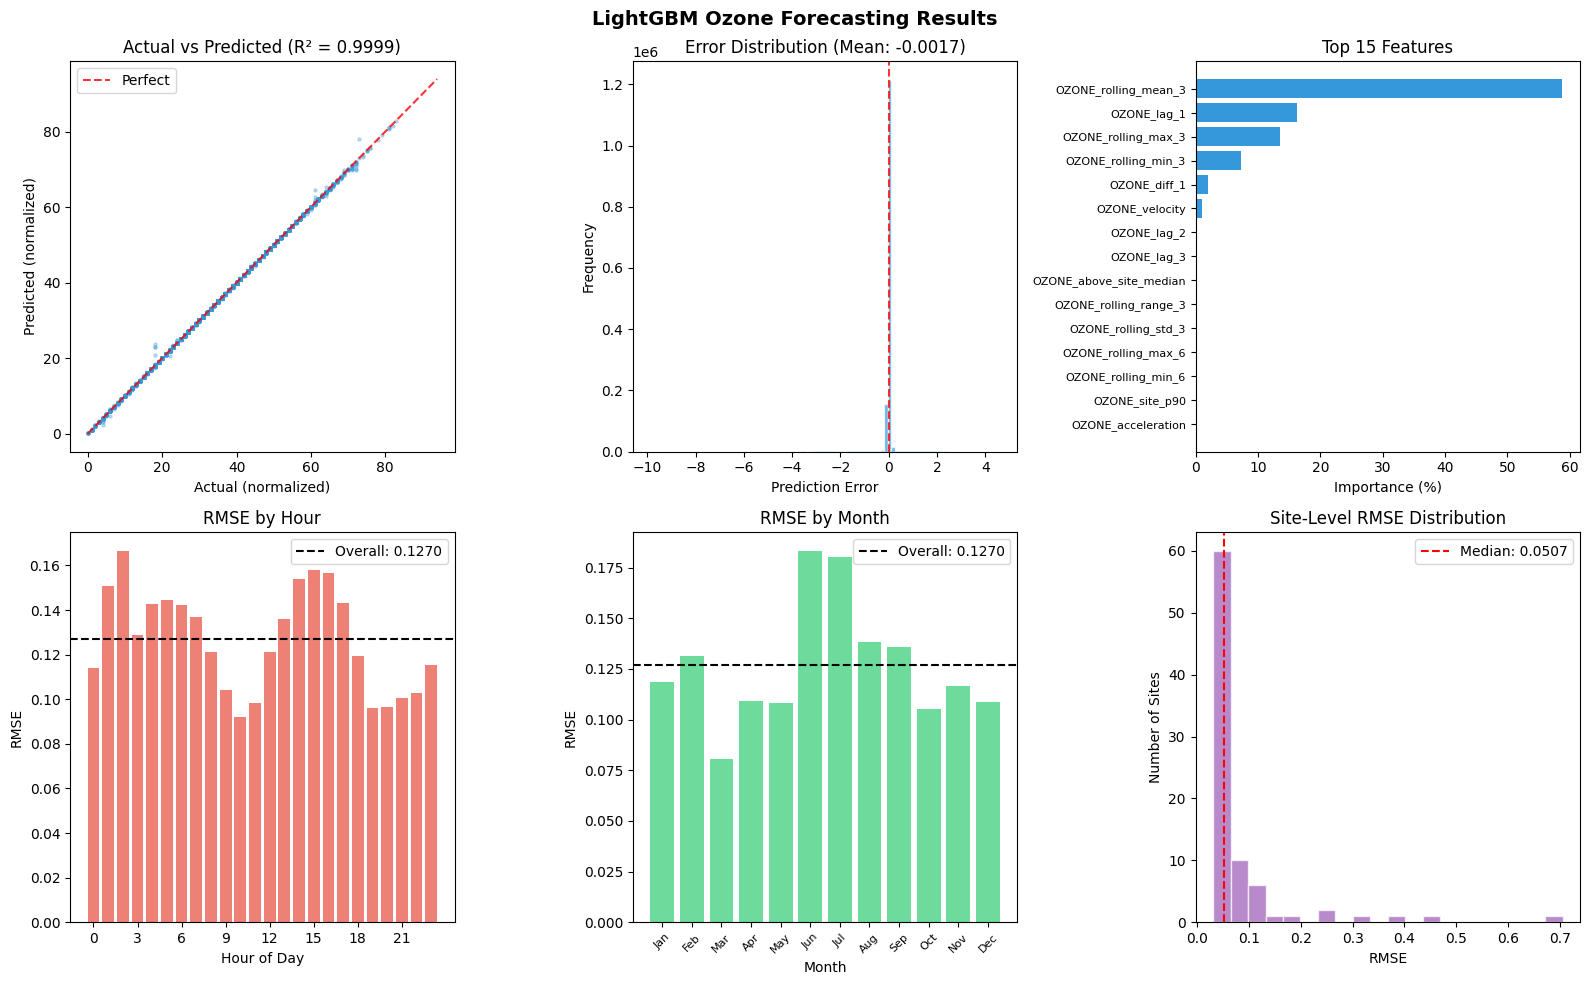

In [ ]:
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('LightGBM Ozone Forecasting Results', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
ax = axes[0, 0]
sample_idx = np.random.choice(len(y_test), min(10000, len(y_test)), replace=False)
ax.scatter(y_test[sample_idx], y_pred_test[sample_idx], alpha=0.3, s=5, c='#3498db')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', alpha=0.8, label='Perfect')
ax.set_xlabel('Actual (normalized)')
ax.set_ylabel('Predicted (normalized)')
ax.set_title(f'Actual vs Predicted (R² = {metrics["R2"]:.4f})')
ax.legend()

# 2. Error distribution
ax = axes[0, 1]
ax.hist(analysis_df['error'], bins=100, alpha=0.7, color='#3498db', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.8)
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean: {analysis_df["error"].mean():.4f})')

# 3. Feature importance (top 15)
ax = axes[0, 2]
top_features = importance_gain.head(15)
ax.barh(range(15), top_features['importance_pct'].values, color='#3498db')
ax.set_yticks(range(15))
ax.set_yticklabels(top_features['feature'].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Importance (%)')
ax.set_title('Top 15 Features')

# 4. RMSE by hour
ax = axes[1, 0]
ax.bar(hourly_rmse.index, hourly_rmse.values, color='#e74c3c', alpha=0.7)
ax.axhline(y=metrics['RMSE'], color='black', linestyle='--', label=f'Overall: {metrics["RMSE"]:.4f}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Hour')
ax.set_xticks(range(0, 24, 3))
ax.legend()

# 5. RMSE by month
ax = axes[1, 1]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.bar(monthly_rmse.index, monthly_rmse.values, color='#2ecc71', alpha=0.7)
ax.axhline(y=metrics['RMSE'], color='black', linestyle='--', label=f'Overall: {metrics["RMSE"]:.4f}')
ax.set_xlabel('Month')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45, fontsize=8)
ax.legend()

# 6. Site RMSE distribution
ax = axes[1, 2]
ax.hist(site_rmse.values, bins=20, color='#9b59b6', alpha=0.7, edgecolor='white')
ax.axvline(x=site_rmse.median(), color='red', linestyle='--', label=f'Median: {site_rmse.median():.4f}')
ax.set_xlabel('RMSE')
ax.set_ylabel('Number of Sites')
ax.set_title('Site-Level RMSE Distribution')
ax.legend()

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'lightgbm_results.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved: {plot_path}")
plt.show()

Generating time series comparison plot...
Time series plot saved: C:\MATH699P\Data\model_outputs\plots\timeseries_sample.png


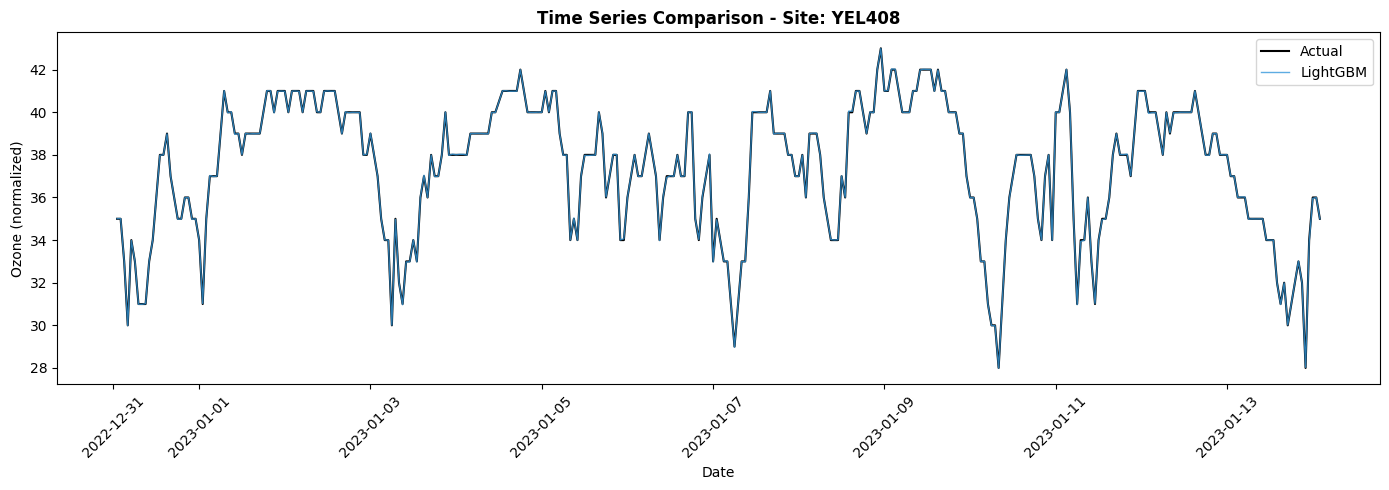

In [14]:
# Time series sample plot
print("Generating time series comparison plot...")

sample_site = analysis_df['SITE_ID'].value_counts().index[0]
site_data = analysis_df[analysis_df['SITE_ID'] == sample_site].sort_values('DATE_TIME').head(168*2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(site_data['DATE_TIME'], site_data['y_true'], label='Actual', color='black', linewidth=1.5)
ax.plot(site_data['DATE_TIME'], site_data['y_pred'], label='LightGBM', color='#3498db', linewidth=1, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Ozone (normalized)')
ax.set_title(f'Time Series Comparison - Site: {sample_site}', fontweight='bold')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

ts_plot_path = os.path.join(PLOTS_DIR, 'timeseries_sample.png')
plt.savefig(ts_plot_path, dpi=300, bbox_inches='tight')
print(f"Time series plot saved: {ts_plot_path}")
plt.show()

## Section 7: Residual Plots

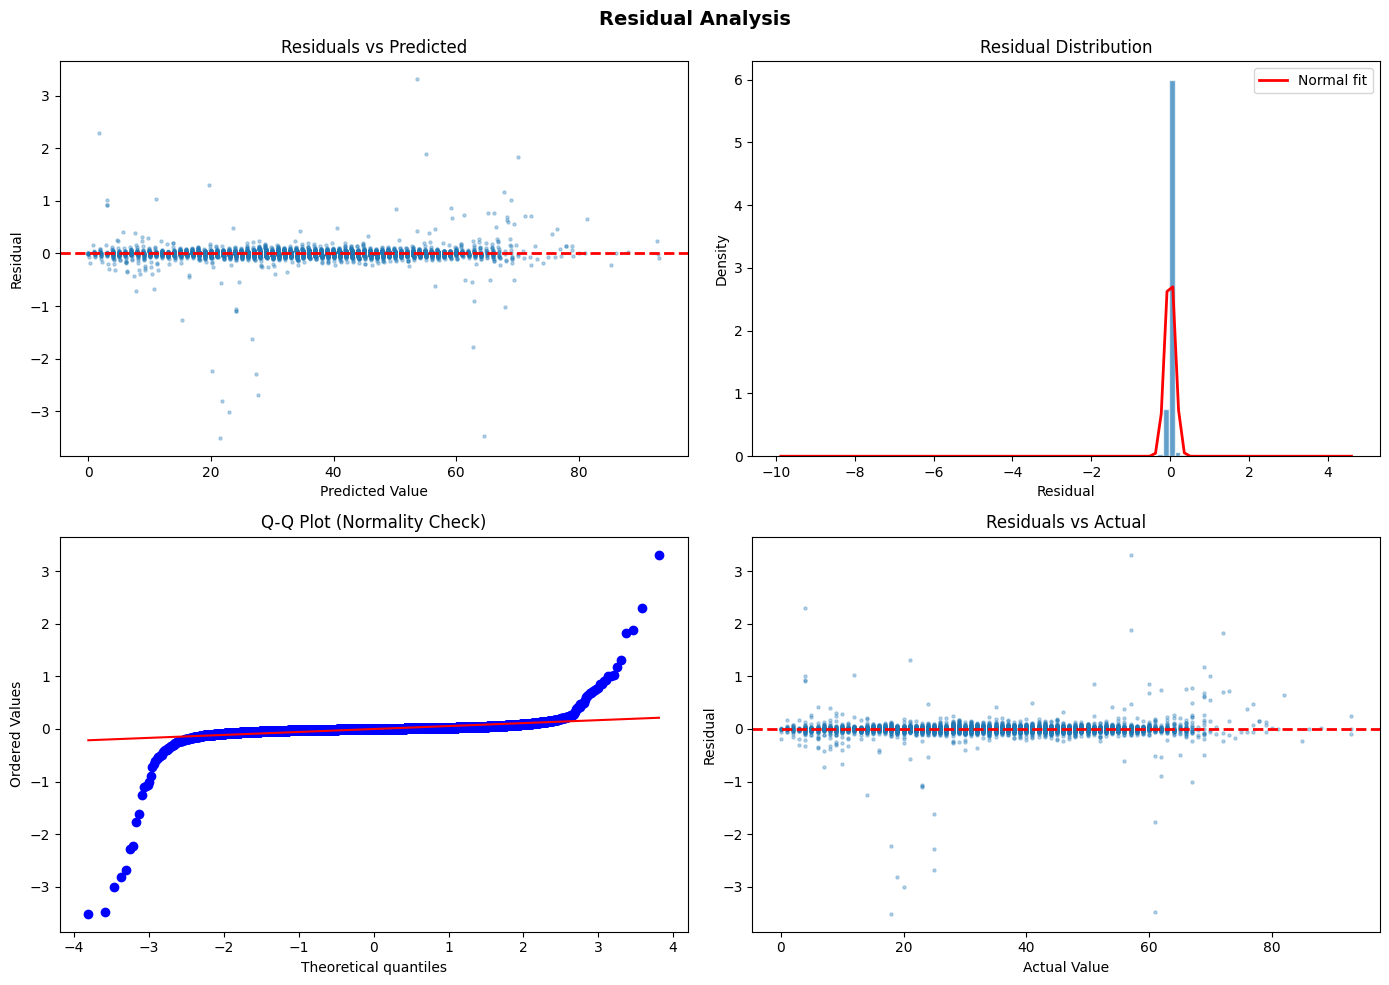

Saved: C:\MATH699P\Data\model_outputs\plots\residual_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

# 1. Residuals vs Predicted
ax = axes[0, 0]
sample_idx = np.random.choice(len(residuals), min(10000, len(residuals)), replace=False)
ax.scatter(y_pred_test[sample_idx], residuals[sample_idx], alpha=0.3, s=5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# 2. Residual histogram
ax = axes[0, 1]
ax.hist(residuals, bins=100, density=True, alpha=0.7, edgecolor='white')
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, np.mean(residuals), np.std(residuals)), 
        'r-', linewidth=2, label='Normal fit')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()

# 3. Q-Q plot
ax = axes[1, 0]
stats.probplot(residuals[sample_idx], dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)')

# 4. Residuals vs Actual
ax = axes[1, 1]
ax.scatter(y_test[sample_idx], residuals[sample_idx], alpha=0.3, s=5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Actual Value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Actual')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'residual_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(PLOTS_DIR, 'residual_analysis.png')}")

## Section 8: Summary Report

In [ ]:
print("\n" + "="*60)
print("MODEL EVALUATION SUMMARY")
print("="*60)

print("\n1. OVERALL PERFORMANCE")
print("-"*40)
print(f"   RMSE:      {metrics['RMSE']:.4f}")
print(f"   MAE:       {metrics['MAE']:.4f}")
print(f"   R²:        {metrics['R2']:.4f}")
print(f"   MAPE:      {metrics['MAPE']:.2f}%")

print("\n2. TEMPORAL PATTERNS")
print("-"*40)
best_hour = hourly_rmse.idxmin()
worst_hour = hourly_rmse.idxmax()
best_month = monthly_rmse.idxmin()
worst_month = monthly_rmse.idxmax()
print(f"   Best hour:   {best_hour}:00 (RMSE: {hourly_rmse[best_hour]:.4f})")
print(f"   Worst hour:  {worst_hour}:00 (RMSE: {hourly_rmse[worst_hour]:.4f})")
print(f"   Best month:  {month_names[best_month-1]} (RMSE: {monthly_rmse[best_month]:.4f})")
print(f"   Worst month: {month_names[worst_month-1]} (RMSE: {monthly_rmse[worst_month]:.4f})")

print("\n3. SITE PERFORMANCE")
print("-"*40)
print(f"   Total sites:     {len(site_rmse)}")
print(f"   Median RMSE:     {site_rmse.median():.4f}")
print(f"   Sites RMSE<0.2:  {(site_rmse < 0.2).sum()}")
print(f"   Sites RMSE>0.3:  {(site_rmse > 0.3).sum()}")

print("\n4. TOP 5 FEATURES")
print("-"*40)
for _, row in importance_gain.head(5).iterrows():
    print(f"   {row['rank']}. {row['feature']:<25s} ({row['importance_pct']:.1f}%)")

print("\n5. RESIDUAL STATISTICS")
print("-"*40)
print(f"   Mean residual:   {np.mean(residuals):.6f}")
print(f"   Std residual:    {np.std(residuals):.4f}")
print(f"   Skewness:        {stats.skew(residuals):.4f}")

print("\n" + "="*60)


MODEL EVALUATION SUMMARY

1. OVERALL PERFORMANCE
----------------------------------------
   RMSE:      0.1270
   MAE:       0.0311
   R²:        0.9999
   MAPE:      0.13%

2. TEMPORAL PATTERNS
----------------------------------------
   Best hour:   10:00 (RMSE: 0.0920)
   Worst hour:  2:00 (RMSE: 0.1666)
   Best month:  Mar (RMSE: 0.0805)
   Worst month: Jun (RMSE: 0.1833)

3. SITE PERFORMANCE
----------------------------------------
   Total sites:     84
   Median RMSE:     0.0507
   Sites RMSE<0.2:  78
   Sites RMSE>0.3:  4

4. TOP 5 FEATURES
----------------------------------------
   1. OZONE_rolling_mean_3      (58.7%)
   2. OZONE_lag_1               (16.2%)
   3. OZONE_rolling_max_3       (13.6%)
   4. OZONE_rolling_min_3       (7.2%)
   5. OZONE_diff_1              (2.0%)

5. RESIDUAL STATISTICS
----------------------------------------
   Mean residual:   -0.001749
   Std residual:    0.1270
   Skewness:        -18.1584



In [ ]:
# Save evaluation report
report_path = os.path.join(RESULTS_DIR, 'evaluation_report.txt')
with open(report_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("LIGHTGBM MODEL EVALUATION REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write("OVERALL METRICS\n")
    f.write("-"*40 + "\n")
    f.write(f"RMSE:      {metrics['RMSE']:.4f}\n")
    f.write(f"MAE:       {metrics['MAE']:.4f}\n")
    f.write(f"R²:        {metrics['R2']:.4f}\n")
    f.write(f"MAPE:      {metrics['MAPE']:.2f}%\n")
    f.write(f"Pearson r: {metrics['Pearson_r']:.4f}\n\n")
    
    f.write("RMSE BY HOUR\n")
    f.write("-"*40 + "\n")
    f.write(hourly_rmse.to_string() + "\n\n")
    
    f.write("RMSE BY MONTH\n")
    f.write("-"*40 + "\n")
    f.write(monthly_rmse.to_string() + "\n\n")
    
    f.write("TOP 10 FEATURES\n")
    f.write("-"*40 + "\n")
    for _, row in importance_gain.head(10).iterrows():
        f.write(f"{row['rank']:2d}. {row['feature']:<30s} {row['importance_pct']:.2f}%\n")

print(f"Report saved: {report_path}")

Report saved: C:\MATH699P\Data\model_outputs\results\evaluation_report.txt


In [ ]:
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)
print(f"\nOutput files:")
print(f"  - {os.path.join(PLOTS_DIR, 'lightgbm_results.png')}")
print(f"  - {os.path.join(PLOTS_DIR, 'timeseries_sample.png')}")
print(f"  - {os.path.join(PLOTS_DIR, 'residual_analysis.png')}")
print(f"  - {os.path.join(RESULTS_DIR, 'prediction_analysis.parquet')}")
print(f"  - {os.path.join(RESULTS_DIR, 'feature_importance.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'evaluation_report.txt')}")


EVALUATION COMPLETE

Output files:
  - C:\MATH699P\Data\model_outputs\plots\lightgbm_results.png
  - C:\MATH699P\Data\model_outputs\plots\timeseries_sample.png
  - C:\MATH699P\Data\model_outputs\plots\residual_analysis.png
  - C:\MATH699P\Data\model_outputs\results\prediction_analysis.parquet
  - C:\MATH699P\Data\model_outputs\results\feature_importance.csv
  - C:\MATH699P\Data\model_outputs\results\evaluation_report.txt
